In [35]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
df = pd.read_csv('exoplanet_data.csv', comment = "#")
print(df.shape)
#583 rows, 92 columns
for col in df.columns:
    print(col)
# pl_controv_flag, pl_orbeccen, pl_insollim, st_met, raster

(583, 92)
pl_name
hostname
default_flag
sy_snum
sy_pnum
discoverymethod
disc_year
disc_facility
soltype
pl_controv_flag
pl_refname
pl_orbper
pl_orbpererr1
pl_orbpererr2
pl_orbperlim
pl_orbsmax
pl_orbsmaxerr1
pl_orbsmaxerr2
pl_orbsmaxlim
pl_rade
pl_radeerr1
pl_radeerr2
pl_radelim
pl_radj
pl_radjerr1
pl_radjerr2
pl_radjlim
pl_bmasse
pl_bmasseerr1
pl_bmasseerr2
pl_bmasselim
pl_bmassj
pl_bmassjerr1
pl_bmassjerr2
pl_bmassjlim
pl_bmassprov
pl_orbeccen
pl_orbeccenerr1
pl_orbeccenerr2
pl_orbeccenlim
pl_insol
pl_insolerr1
pl_insolerr2
pl_insollim
pl_eqt
pl_eqterr1
pl_eqterr2
pl_eqtlim
ttv_flag
st_refname
st_spectype
st_teff
st_tefferr1
st_tefferr2
st_tefflim
st_rad
st_raderr1
st_raderr2
st_radlim
st_mass
st_masserr1
st_masserr2
st_masslim
st_met
st_meterr1
st_meterr2
st_metlim
st_metratio
st_logg
st_loggerr1
st_loggerr2
st_logglim
sy_refname
rastr
ra
decstr
dec
sy_dist
sy_disterr1
sy_disterr2
sy_vmag
sy_vmagerr1
sy_vmagerr2
sy_kmag
sy_kmagerr1
sy_kmagerr2
sy_gaiamag
sy_gaiamagerr1
sy_gaiamagerr

In [23]:
# Planet Name: pl_name
# Host Name: hostname -- the specific star an exoplanet orbits
# Discovery MethodL discoverymethod
# Spectral Type: st_spectype -- the kind of color witnessed of an exoplanet that can denote important atributes
# Equilibrium Temperature [K]: pl_eqt -- the theoretical temperature an exoplanet would reach if it were only heated by its star
# Planet Mass [Jupiter Mass]: pl_bmassj -- units to describe large exoplanets
columns_to_keep = ['pl_name', 'hostname', 'discoverymethod', 'st_spectype', 'pl_eqt', 'pl_bmassj']
df_small = df[columns_to_keep]
df_filter = df_small.dropna(axis = 0, how = 'any')
print(df_filter.shape)
# 70 rows, 6 columns
print(df_filter.head(5))
print(df_filter.tail(5))
print(df_filter.columns)

(70, 6)
     pl_name hostname  discoverymethod st_spectype  pl_eqt  pl_bmassj
3   DMPP-1 b   DMPP-1  Radial Velocity        F8 V   877.0   0.076362
5   DMPP-1 c   DMPP-1  Radial Velocity        F8 V  1239.0   0.030205
7   DMPP-1 d   DMPP-1  Radial Velocity        F8 V  1632.0   0.010540
8   DMPP-1 e   DMPP-1  Radial Velocity        F8 V  1314.0   0.012994
10  DMPP-2 b   DMPP-2  Radial Velocity        F5 V  1000.0   0.437000
         pl_name   hostname  discoverymethod st_spectype  pl_eqt  pl_bmassj
561   WASP-185 b   WASP-185          Transit        G0 V  1160.0      0.980
565   WASP-190 b   WASP-190          Transit     F6 IV-V  1500.0      1.000
569   WASP-192 b   WASP-192          Transit        G0 V  1620.0      2.300
572       XO-7 b       XO-7          Transit        G0 V  1743.0      0.709
581  eps Ind A b  eps Ind A  Radial Velocity        K5 V   275.0      6.310
pl_name
hostname
discoverymethod
st_spectype
pl_eqt
pl_bmassj
Index(['pl_name', 'hostname', 'discoverymethod', 'st_s

discoverymethod
Transit            55
Radial Velocity    13
Imaging             2
Name: count, dtype: int64
pl_name                eps Ind A b
hostname                 eps Ind A
discoverymethod    Radial Velocity
st_spectype                   K5 V
pl_eqt                       275.0
pl_bmassj                     6.31
Name: 581, dtype: object


<function matplotlib.pyplot.show(close=None, block=None)>

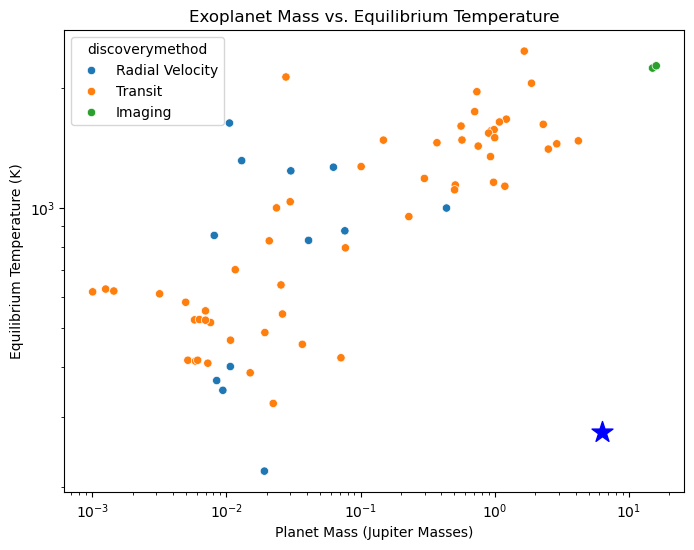

In [45]:
methods = df_filter['discoverymethod'].value_counts()
print(methods)
# Transit has the most, with imaging having the least
# Transit method: looking for dips in star brightness to determine a planet passing by it
# Radial velocity: looks for the slight movement of a star caused by the gravity of an exoplanet
# Imaging: high-contrast imagery used to capture light directly from a star from a host star's intense glare
plt.figure (figsize = (8, 6))
sns.scatterplot(data = df_filter, x = 'pl_bmassj', y = 'pl_eqt', hue = 'discoverymethod')

plt.title("Exoplanet Mass vs. Equilibrium Temperature")
plt.xlabel("Planet Mass (Jupiter Masses)")
plt.ylabel("Equilibrium Temperature (K)")
plt.legend
plt.show
plt.xscale('log')
plt.yscale('log')
plt.show
# With the imaging method, the planets are more likely to be massive
massive_planets = df_filter[df_filter['pl_bmassj'] > 5]
coldest = massive_planets['pl_eqt'].idxmin()
coldest_massive = df_filter.loc[coldest]
print(df_filter.loc[coldest])
# Its name is eps Ind A b
# It's on index 581
# 275.0 K
# 6.31 Jupiters
# It's orbiting star eps Ind A
plt.scatter(x = coldest_massive['pl_bmassj'], y = coldest_massive['pl_eqt'], color = 'blue', marker = '*', s = 250, label = f"Coldest: {coldest_massive['pl_name']}")
plt.legend
plt.show
#TitleL A temperature super_Jupiter imaged with JWST in the mid-infrared
#A super large planet recently discovered that has oddly life-convenient environment and is orbiting eps Ind A
#My answer does match the exoplanet
#This is the only giant planet in the system
#The mass is very large (fitting the description from Nature) and the temperature 275.0 K is that good range described for supporting life.